# RealLift Demonstration

RealLift is a Causal Inference library for Lift Measurement, specifically designed for Geo-experiments.

This notebook demonstrates how to:
1. Install the library.
2. Generate synthetic data.
3. Run a GeoLift experiment pipeline.
4. Interpret the results.

## 1. Installation

In [1]:
# Note: In Google Colab, you can install directly from GitHub if the repo is public
# %pip install git+https://github.com/yourusername/reallift.git

# For now, since we are in a local environment or testing, we install from the current directory
#%pip install reallift

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from reallift import generate_geolift_data
from reallift.geo.split import find_best_geo_split, build_geo_clusters
from reallift.geo.duration import estimate_duration
from reallift.geo.validation import validate_geo_groups
from reallift.geo.synthetic import run_synthetic_control

## 2. Generate Synthetic Data

We will simulate data for 10 geographical areas over 6 months.

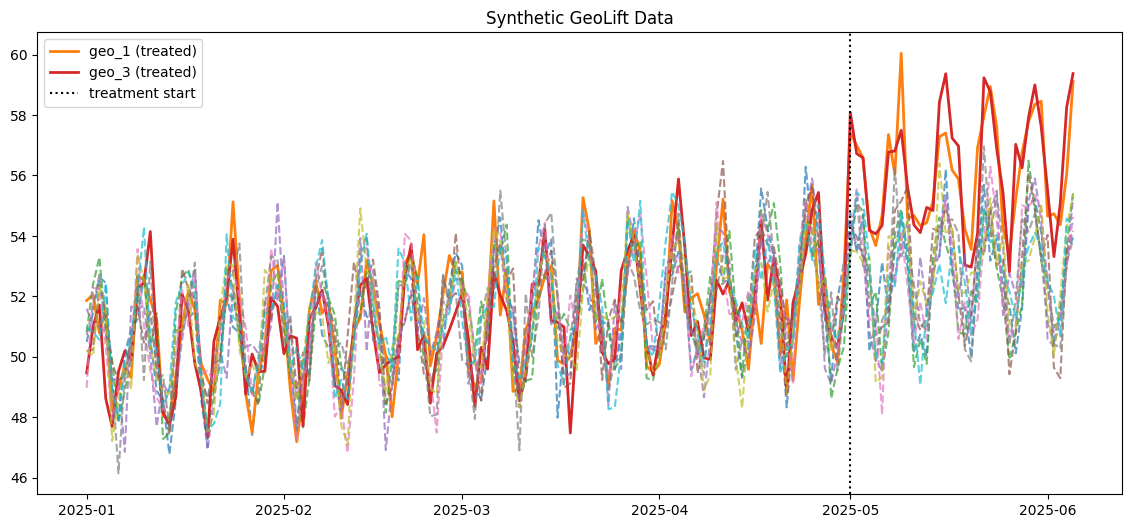

In [4]:
# Parameters for simulation
file_pre_test = 'demo_geodata_pre_test.csv'
file_post_test = 'demo_geodata_post_test.csv'
start_date = "2025-01-01"
treatment_start = pd.to_datetime("2025-05-01")
end_date = treatment_start + pd.Timedelta(days=35)

df, df_pre, treated = generate_geolift_data(
    start_date = start_date,
    treatment_start = treatment_start,
    end_date = end_date,
    n_geos=10,
    treatment_geos=["geo_1", "geo_3"],
    lift=0.06,  # lift post test
    trend_slope=0.02,
    seasonality_amplitude=2,
    seasonality_period=7,
    noise_std=1,
    save_csv=True,
    save_pre_only=True,
    file_name=file_post_test,
    pre_file_name=file_pre_test
)

In [ ]:
splits = find_best_geo_split(
    filepath=file_pre_test,
    date_col="date",
    n_treatment=1,
    fixed_treatment=["geo_1", "geo_3"],
)


In [ ]:
clusters = build_geo_clusters(splits)

In [ ]:
for cluster in clusters:
    res = estimate_duration(
        filepath=file_pre_test,
        date_col="date",
        treatment_geo=cluster["treatment"][0],
        control_geos=cluster["control"],
        mde=0.015,
        max_days=60
    )
    print(res)

In [ ]:
validation = validate_geo_groups(
    filepath=file_pre_test,
    date_col="date",
    splits=splits,
    train_test_split=0.25,
    plot=True,
    export_csv=False,
)

In [ ]:
for cluster in clusters:
  result = run_synthetic_control(
      filepath=file_post_test,
      date_col="date",
      treatment_geo=cluster['treatment'][0],
      control_geos=cluster['control'],
      treatment_start_date=treatment_start
  )

In [ ]:
from reallift.geo.placebo import run_placebo_tests

In [ ]:
from reallift.pipelines.geo_pipeline import run_geo_experiment

In [ ]:
for cluster in clusters:
    placebo = run_placebo_tests(
        filepath=file_post_test,
        date_col='date',
        control_geos=cluster["control"],
        treatment_start_date=treatment_start,
        observed_lift=113.02
    )


In [5]:
from reallift.pipelines.geo_pipeline import run_geo_experiment
run_geo_experiment(
    filepath=file_post_test,
    date_col='date',
    treatment_start_date=treatment_start,
    geos=None,
    n_treatment=1,
    fixed_treatment=["geo_1", "geo_3"],
    mde=0.015,
    max_days=60,
    plot=False,
    verbose=True,
    random_state=42
)


=== BEST COMBINATION ===
{'treatment': ['geo_1', 'geo_3'], 'control': ['geo_0', 'geo_2', 'geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_9'], 'std_residual': 0.022132980313664154, 'correlation': 0.7137016583561671, 'n_controls': 7, 'alpha': 0.001, 'l1_ratio': 0.2}

VALIDAÇÃO DO SPLIT 0
Tratamento: ['geo_1', 'geo_3']
Controle: ['geo_0', 'geo_2', 'geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_9']

--- MODELO NÍVEL (FINAL) ---
Train size: 90
Test size: 30
R2 Train: 0.7439
R2 Test: 0.7026
R2 Full: 0.7586
MAPE Train: 0.0125
MAPE Test: 0.0125
MAPE Full: 0.0125
WAPE Train: 0.0126
WAPE Test: 0.0126
WAPE Full: 0.0126

=== GEO EXPERIMENT SETUP ===
Treatment: geo_1
Control: ['geo_0', 'geo_2', 'geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_9']

=== STATISTICS ===
Mean: 52.38
Std naive: 2.74
Std residual (mean): 1.75
Std residual (regression): 0.0292
Correlation: 0.787

=== MDE ===
MDE: 1.50%
Effect absolute: 0.79
Effect percent real: 1.50%

=== RESULT (REGRESSION) ===
✔ Min duration: 31 days
✔ Power: 80.99%

=== SY

{'summary': {'splits': {'treatment': ['geo_1', 'geo_3'],
   'control': ['geo_0', 'geo_2', 'geo_4', 'geo_6', 'geo_7', 'geo_8', 'geo_9'],
   'std_residual': 0.022132980313664154,
   'correlation': 0.7137016583561671,
   'n_controls': 7,
   'alpha': 0.001,
   'l1_ratio': 0.2},
  'clusters': [{'treatment': ['geo_1'],
    'control': ['geo_0',
     'geo_2',
     'geo_4',
     'geo_6',
     'geo_7',
     'geo_8',
     'geo_9']},
   {'treatment': ['geo_3'],
    'control': ['geo_0',
     'geo_2',
     'geo_4',
     'geo_6',
     'geo_7',
     'geo_8',
     'geo_9']}]},
 'results': [{'cluster': {'treatment': ['geo_1'],
    'control': ['geo_0',
     'geo_2',
     'geo_4',
     'geo_6',
     'geo_7',
     'geo_8',
     'geo_9']},
   'validation': {'summary':         treatment                                            control  \
    0  [geo_1, geo_3]  [geo_0, geo_2, geo_4, geo_6, geo_7, geo_8, geo_9]   
    
       r2_train  r2_test   r2_full  mape_test  wape_test  
    0  0.743944  0.70264  0.758